# 01 -- Data Exploration with PySpark

Explore the Project Gutenberg sample dataset using PySpark in local mode.

**Goals:**
- Load book .txt files into Spark
- Compute basic statistics (count, word count, file size)
- Demo text cleaning pipeline
- Verify data readiness for LSH

In [ ]:
import os, sys
# Databricks Free Edition (Serverless) auto-mounts Git folders under /Workspace/Repos/.
_in_databricks = os.path.exists("/Workspace") and "DATABRICKS_RUNTIME_VERSION" in os.environ
if _in_databricks:
    os.environ.setdefault("LSH_ENV", "databricks")
    _candidates = [os.getcwd()] + [
        f"/Workspace/Repos/{os.environ.get('USER', '')}/lsh-book-recommendation"
    ]
    _repo_root = next(
        (p for p in _candidates
         if os.path.isdir(os.path.join(p, "config")) and os.path.isdir(os.path.join(p, "src"))),
        os.getcwd(),
    )
    if _repo_root not in sys.path:
        sys.path.insert(0, _repo_root)
    os.environ.setdefault(
        "NLTK_DATA",
        "/Volumes/workspace/lsh_book_recommendation/data/nltk_data",
    )
else:
    if os.path.basename(os.getcwd()) == "notebooks":
        os.chdir(os.path.abspath(os.path.join(os.getcwd(), "..")))
    sys.path.insert(0, ".")

from config.settings import config
from scripts import clean_gutenberg_text

print(f"Environment: {config.ENV}")
print(f"Spark master: {config.SPARK_MASTER}")
print(f"Data path: {config.DATA_RAW_PATH}")
print(f"Working dir: {os.getcwd()}")


In [2]:
from pyspark.sql import SparkSession

spark = (
    SparkSession.builder
    .master(config.SPARK_MASTER)
    .appName(config.SPARK_APP_NAME)
    .config("spark.driver.memory", config.SPARK_DRIVER_MEMORY)
    .config("spark.executor.memory", config.SPARK_EXECUTOR_MEMORY)
    .config("spark.ui.showConsoleProgress", "false")
    .getOrCreate()
)

sc = spark.sparkContext
print(f"Spark version: {spark.version}")
print(f"Master: {sc.master}")
print(f"Parallelism: {sc.defaultParallelism}")

Setting default log level to "WARN".
To adjust logging level use sc.setLogLevel(newLevel). For SparkR, use setLogLevel(newLevel).
26/03/03 02:46:57 WARN NativeCodeLoader: Unable to load native-hadoop library for your platform... using builtin-java classes where applicable


Spark version: 3.5.8
Master: local[*]
Parallelism: 10


## 1. Load Book Files
Read all .txt files from `data/sample/` into a Spark DataFrame.

In [3]:
sample_dir = config.DATA_RAW_PATH
files = [f for f in os.listdir(sample_dir) if f.endswith(".txt")]
print(f"Found {len(files)} book files")

# Read all text files using wholeTextFiles (returns (path, content) pairs)
rdd = sc.wholeTextFiles(f"file://{os.path.abspath(sample_dir)}/*.txt")
print(f"RDD partitions: {rdd.getNumPartitions()}")
print(f"Total books loaded: {rdd.count()}")

Found 93 book files
RDD partitions: 2
Total books loaded: 93


In [4]:
from pyspark.sql import Row

def parse_book(pair):
    path, content = pair
    filename = os.path.basename(path)
    book_id = filename.replace("pg", "").replace(".txt", "")
    lines = content.split("\n")
    words = content.split()
    return Row(
        book_id=book_id,
        filename=filename,
        num_lines=len(lines),
        num_words=len(words),
        num_chars=len(content),
    )

books_df = rdd.map(parse_book).toDF()
books_df.cache()
books_df.show(10, truncate=False)

+-------+-----------+---------+---------+---------+
|book_id|filename   |num_lines|num_words|num_chars|
+-------+-----------+---------+---------+---------+
|10007  |pg10007.txt|1        |28189    |154333   |
|1026   |pg1026.txt |1        |42240    |226531   |
|103    |pg103.txt  |1        |63460    |364574   |
|10444  |pg10444.txt|1        |82687    |496117   |
|10554  |pg10554.txt|1        |73822    |396425   |
|11592  |pg11592.txt|1        |2696     |14357    |
|1184   |pg1184.txt |1        |463235   |2577504  |
|12027  |pg12027.txt|1        |67318    |384686   |
|12116  |pg12116.txt|1        |2361     |12570    |
|1250   |pg1250.txt |1        |19165    |96965    |
+-------+-----------+---------+---------+---------+
only showing top 10 rows



## 2. Basic Statistics

In [5]:
from pyspark.sql import functions as F

stats = books_df.agg(
    F.count("book_id").alias("total_books"),
    F.mean("num_words").cast("int").alias("avg_words"),
    F.min("num_words").alias("min_words"),
    F.max("num_words").alias("max_words"),
    F.mean("num_chars").cast("int").alias("avg_chars"),
    F.sum("num_words").alias("total_words"),
)
stats.show(truncate=False)

+-----------+---------+---------+---------+---------+-----------+
|total_books|avg_words|min_words|max_words|avg_chars|total_words|
+-----------+---------+---------+---------+---------+-----------+
|93         |78444    |1012     |623794   |443793   |7295376    |
+-----------+---------+---------+---------+---------+-----------+



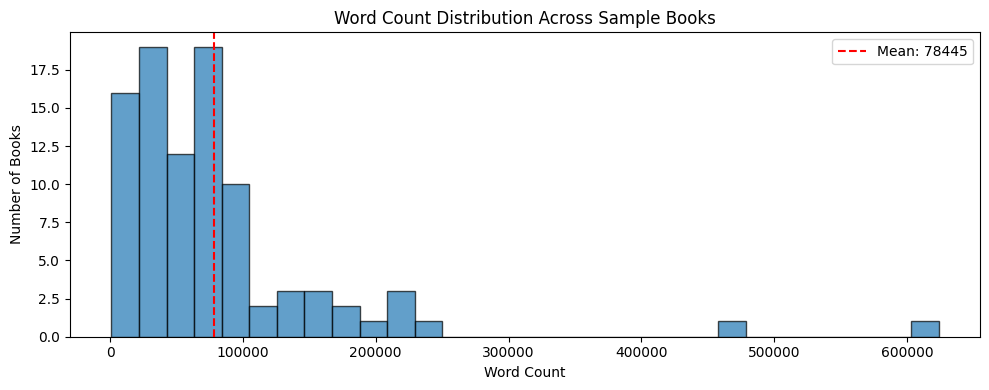

In [6]:
import matplotlib.pyplot as plt

pdf = books_df.select("book_id", "num_words").toPandas()

fig, ax = plt.subplots(figsize=(10, 4))
ax.hist(pdf["num_words"], bins=30, edgecolor="black", alpha=0.7)
ax.set_xlabel("Word Count")
ax.set_ylabel("Number of Books")
ax.set_title("Word Count Distribution Across Sample Books")
ax.axvline(pdf["num_words"].mean(), color="red", linestyle="--", label=f"Mean: {pdf['num_words'].mean():.0f}")
ax.legend()
plt.tight_layout()
plt.show()

## 3. Text Cleaning Demo
Use `scripts.clean_gutenberg_text()` to strip Gutenberg headers/footers and normalize text.

In [7]:
# Pick one book to demonstrate cleaning
sample_path, sample_content = rdd.first()
sample_name = os.path.basename(sample_path)

print(f"Book: {sample_name}")
print(f"Raw length: {len(sample_content)} chars")
print(f"\n--- RAW (first 300 chars) ---")
print(sample_content[:300])

cleaned = clean_gutenberg_text(sample_content)
print(f"\n--- CLEANED (first 300 chars) ---")
print(cleaned[:300])
print(f"\nCleaned length: {len(cleaned)} chars")
print(f"Reduction: {(1 - len(cleaned)/len(sample_content))*100:.1f}%")

Book: pg10007.txt
Raw length: 154333 chars

--- RAW (first 300 chars) ---
Carmilla by Joseph Sheridan Le Fanu Copyright 1872 Contents PROLOGUE CHAPTER I. An Early Fright CHAPTER II. A Guest CHAPTER III. We Compare Notes CHAPTER IV. Her Habits A Saunter CHAPTER V. A Wonderful Likeness CHAPTER VI. A Very Strange Agony CHAPTER VII. Descending CHAPTER VIII. Search CHAPTER IX.

--- CLEANED (first 300 chars) ---
Carmilla by Joseph Sheridan Le Fanu Copyright 1872 Contents PROLOGUE CHAPTER I. An Early Fright CHAPTER II. A Guest CHAPTER III. We Compare Notes CHAPTER IV. Her Habits A Saunter CHAPTER V. A Wonderful Likeness CHAPTER VI. A Very Strange Agony CHAPTER VII. Descending CHAPTER VIII. Search CHAPTER IX.

Cleaned length: 154333 chars
Reduction: 0.0%


In [8]:
from pyspark.sql.functions import udf
from pyspark.sql.types import StringType, IntegerType

# Register UDF for cleaning
clean_udf = udf(clean_gutenberg_text, StringType())
word_count_udf = udf(lambda text: len(text.split()) if text else 0, IntegerType())

# Reload with content column
books_with_text = rdd.map(
    lambda pair: Row(
        book_id=os.path.basename(pair[0]).replace("pg", "").replace(".txt", ""),
        raw_text=pair[1],
    )
).toDF()

cleaned_df = (
    books_with_text
    .withColumn("cleaned_text", clean_udf("raw_text"))
    .withColumn("raw_words", word_count_udf("raw_text"))
    .withColumn("cleaned_words", word_count_udf("cleaned_text"))
    .select("book_id", "raw_words", "cleaned_words")
)

cleaned_df.cache()
cleaned_df.show(10)

# Summary
cleaned_df.agg(
    F.mean("raw_words").cast("int").alias("avg_raw_words"),
    F.mean("cleaned_words").cast("int").alias("avg_cleaned_words"),
).show()

+-------+---------+-------------+
|book_id|raw_words|cleaned_words|
+-------+---------+-------------+
|  10007|    28189|        28189|
|   1026|    42240|        42240|
|    103|    63460|        63460|
|  10444|    82687|        82687|
|  10554|    73822|        73822|
|  11592|     2696|         2696|
|   1184|   463235|       463235|
|  12027|    67318|        67318|
|  12116|     2361|         2361|
|   1250|    19165|        19165|
+-------+---------+-------------+
only showing top 10 rows

+-------------+-----------------+
|avg_raw_words|avg_cleaned_words|
+-------------+-----------------+
|        78444|            78444|
+-------------+-----------------+



## 4. Data Readiness for LSH Pipeline

The data is ready for the LSH pipeline:
- Books loaded into Spark DataFrames
- Text cleaning removes Gutenberg boilerplate
- Each book has a unique ID (from filename)
- Cleaned text ready for: shingling -> minhash -> LSH bucketing

**Next steps:** `02_preprocessing_demo.ipynb`

In [9]:
# Show top 10 books by word count after cleaning
sample_cleaned = cleaned_df.join(
    books_with_text, on="book_id"
).select("book_id", "cleaned_words").orderBy(F.desc("cleaned_words"))

print("Top 10 books by word count (after cleaning):")
sample_cleaned.show(10, truncate=False)

Top 10 books by word count (after cleaning):
+-------+-------------+
|book_id|cleaned_words|
+-------+-------------+
|2760   |623794       |
|1184   |463235       |
|1257   |230133       |
|1468   |227315       |
|1320   |226457       |
|24790  |212861       |
|14287  |196347       |
|3317   |183681       |
|18247  |175699       |
|699    |163573       |
+-------+-------------+
only showing top 10 rows



In [10]:
spark.stop()
print("SparkSession stopped. Data exploration complete.")

SparkSession stopped. Data exploration complete.
